In [26]:
import sys
sys.path.append('../src')
import numpy as np
import common

## 1. Test `note_to_freq` and `freq_to_note`

A few known reference points:
- MIDI 69 (A4) must be exactly 440 Hz (it's the tuning reference).
- MIDI 60 is C4 ("middle C"), commonly quoted as ~261.63 Hz.
- MIDI 57 is A3, one octave below A4, so it should be exactly 220 Hz.

In [27]:
print(common.note_to_freq(69))   # expect 440.0
print(common.note_to_freq(60))   # expect ~261.6256 (middle C)
print(common.note_to_freq(57))   # expect 220.0 (one octave below A4)

assert common.note_to_freq(69) == 440.0
assert abs(common.note_to_freq(60) - 261.6256) < 1e-3
assert common.note_to_freq(57) == 220.0
print("note_to_freq OK")

440.0
261.6255653005986
220.0
note_to_freq OK


In [28]:
print(common.freq_to_note(440.0))   # expect ('A', 4, 69)
print(common.freq_to_note(261.63))  # expect ('C', 4, 60)
print(common.freq_to_note(220.0))   # expect ('A', 3, 57)

assert common.freq_to_note(440.0) == ('A', 4, 69)
assert common.freq_to_note(261.63) == ('C', 4, 60)
assert common.freq_to_note(220.0) == ('A', 3, 57)
print("freq_to_note OK")

('A', 4, 69)
('C', 4, 60)
('A', 3, 57)
freq_to_note OK


**Round trip:** for every MIDI number in a reasonable range, converting to frequency and back should return the same MIDI number (this is the property `pitch.py` will lean on when turning a detected frequency into a note name).

In [29]:
for m in range(21, 109):  # A0 .. C8, standard piano range
    f = common.note_to_freq(m)
    _, _, m_back = common.freq_to_note(f)
    assert m_back == m, f"round-trip failed for MIDI {m}: got {m_back}"
print("round-trip note_to_freq -> freq_to_note OK for MIDI 21-108")

round-trip note_to_freq -> freq_to_note OK for MIDI 21-108


**Edge case:** `freq_to_note` on a non-positive frequency should return `(None, None, None)` rather than crashing (because `log2` of a non-positive number is undefined).

In [30]:
print(common.freq_to_note(0))
print(common.freq_to_note(-10))

assert common.freq_to_note(0) == (None, None, None)
assert common.freq_to_note(-10) == (None, None, None)
print("freq_to_note edge case OK")

(None, None, None)
(None, None, None)
freq_to_note edge case OK


## 2. Test `freq_to_chroma`

It should fold octaves away: A3, A4, and A5 are all different frequencies but the same pitch class (9 = 'A' in `NOTE_NAMES`).

In [31]:
print(common.freq_to_chroma(220.0))   # A3 -> 9
print(common.freq_to_chroma(440.0))   # A4 -> 9
print(common.freq_to_chroma(880.0))   # A5 -> 9
print(common.freq_to_chroma(261.63))  # C4 -> 0

assert common.freq_to_chroma(220.0) == 9
assert common.freq_to_chroma(440.0) == 9
assert common.freq_to_chroma(880.0) == 9
assert common.freq_to_chroma(261.63) == 0
print("freq_to_chroma OK")

9
9
9
0
freq_to_chroma OK


## 3. Test `generate_tone`

Checks: correct sample count, a pure sine (`num_harmonics=1`) should have most of its energy at f0 in the DFT, and `noise_std=0` should give a perfectly periodic, noise-free signal.

In [32]:
Fs = 44100
duration = 0.5
f0 = 440.0

tone = common.generate_tone(f0, duration, Fs)
expected_len = len(np.arange(0, duration, 1.0 / Fs))
print("length:", len(tone), "expected:", expected_len)

assert len(tone) == expected_len
print("generate_tone length OK")

length: 22050 expected: 22050
generate_tone length OK


peak frequency: 440.0 Hz (expected close to 440 Hz)
generate_tone frequency content OK


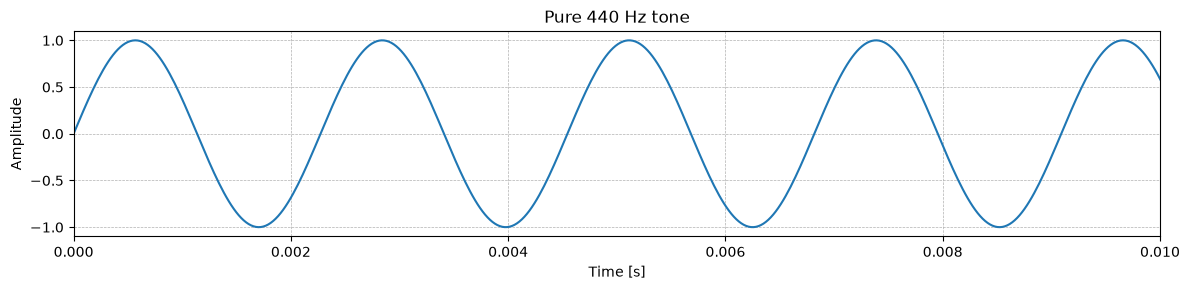

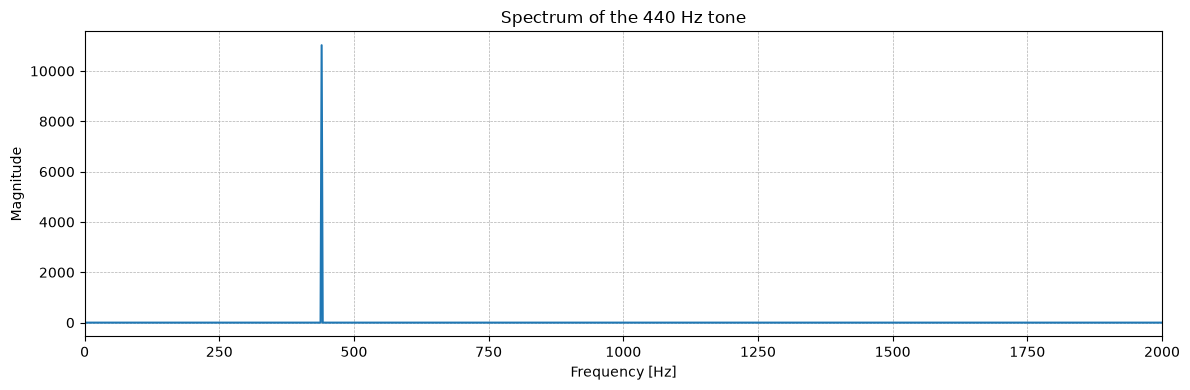

In [33]:
# A pure sine's energy should peak at f0 in the spectrum
spectrum = np.fft.rfft(tone)
freqs = np.fft.rfftfreq(len(tone), d=1.0 / Fs)
peak_freq = freqs[np.argmax(np.abs(spectrum))]
print("peak frequency:", peak_freq, "Hz (expected close to 440 Hz)")
assert abs(peak_freq - f0) < 5  # within about one FFT bin or so
print("generate_tone frequency content OK")

common.plot_signal(tone, Fs, title='Pure 440 Hz tone', xlim=(0, 0.01))
common.plot_spectrum(freqs, spectrum, title='Spectrum of the 440 Hz tone', xlim=(0, 2000))

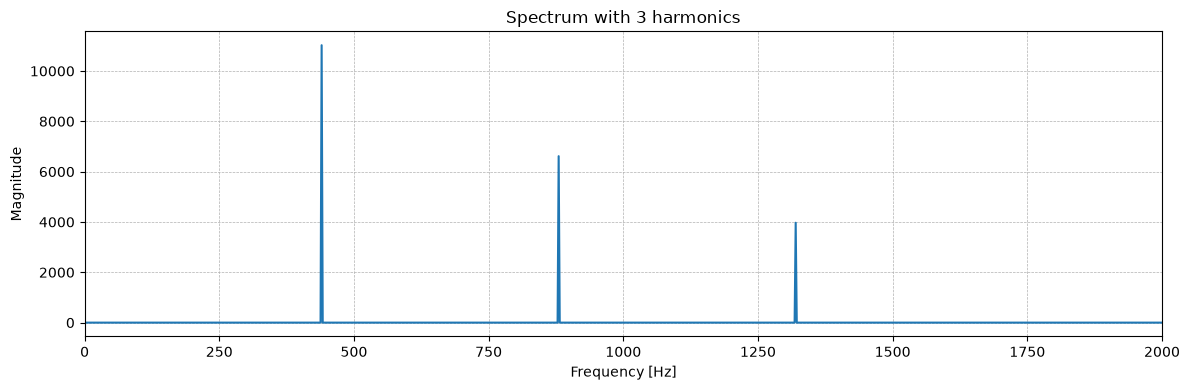

In [34]:
# With harmonics, the spectrum should also show peaks near 2*f0, 3*f0, ...
tone_harm = common.generate_tone(f0, duration, Fs, num_harmonics=3, decay=0.6)
spectrum_h = np.fft.rfft(tone_harm)
freqs_h = np.fft.rfftfreq(len(tone_harm), d=1.0 / Fs)
common.plot_spectrum(freqs_h, spectrum_h, title='Spectrum with 3 harmonics', xlim=(0, 2000))

## 4. Test `generate_chord`

An A major chord (A3, C#4, E4) should show peaks at all three fundamentals, and normalizing by the number of notes should keep the signal from clipping much beyond amplitude 1.

length: 22050 expected: 22050
peak magnitude (should not blow up): 1.3869832528133685


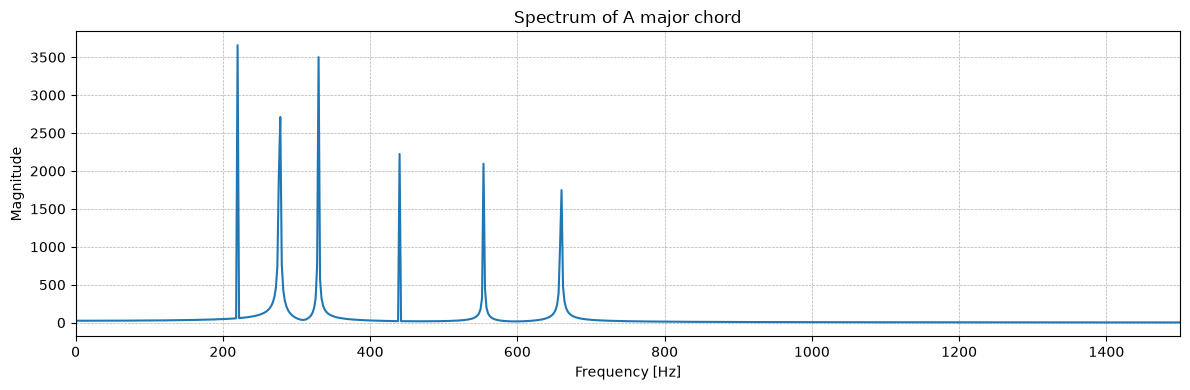

In [35]:
a_major = [220.00, 277.18, 329.63]  # A3, C#4, E4
chord = common.generate_chord(a_major, duration, Fs, num_harmonics=2)

expected_len = len(np.arange(0, duration, 1.0 / Fs))
print("length:", len(chord), "expected:", expected_len)
assert len(chord) == expected_len

spectrum_c = np.fft.rfft(chord)
freqs_c = np.fft.rfftfreq(len(chord), d=1.0 / Fs)
common.plot_spectrum(freqs_c, spectrum_c, title='Spectrum of A major chord', xlim=(0, 1500))
print("peak magnitude (should not blow up):", np.max(np.abs(chord)))

## 5. Test `load_wav`

Loaded against the real `piano.wav` from `data/`. Checks: mono output, `float64` dtype, and amplitude normalized into `[-1, 1]`.

Fs: 44100
shape: (222821,)
dtype: float64
min/max: -1.0 0.8022640923458461
load_wav OK


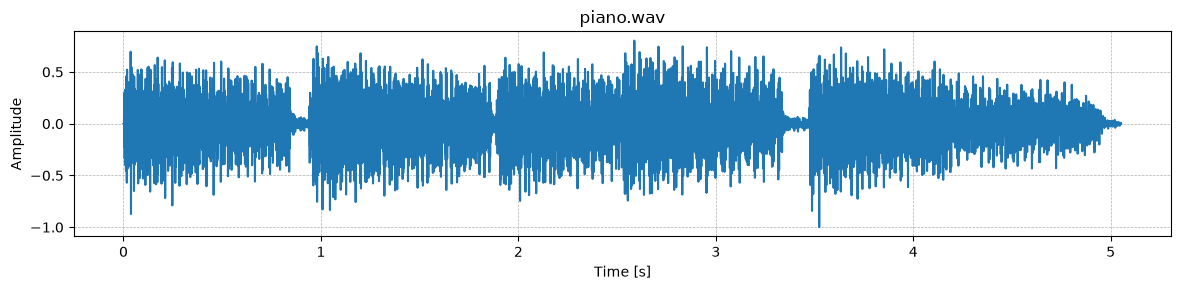

In [36]:
Fs_wav, signal_wav = common.load_wav('../data/piano.wav')

print("Fs:", Fs_wav)
print("shape:", signal_wav.shape)
print("dtype:", signal_wav.dtype)
print("min/max:", signal_wav.min(), signal_wav.max())

assert signal_wav.ndim == 1 # mono
assert signal_wav.dtype == np.float64
assert signal_wav.max() <= 1.0
assert signal_wav.min() >= -1.0
print("load_wav OK")

common.plot_signal(signal_wav, Fs_wav, title='piano.wav')

## 6. Test `plot_signal` and `plot_spectrum`

Already exercised above as part of the other tests (a plot that renders without errors is the check, since these are visualization-only functions). One more direct call here for completeness, on the chord from section 4.

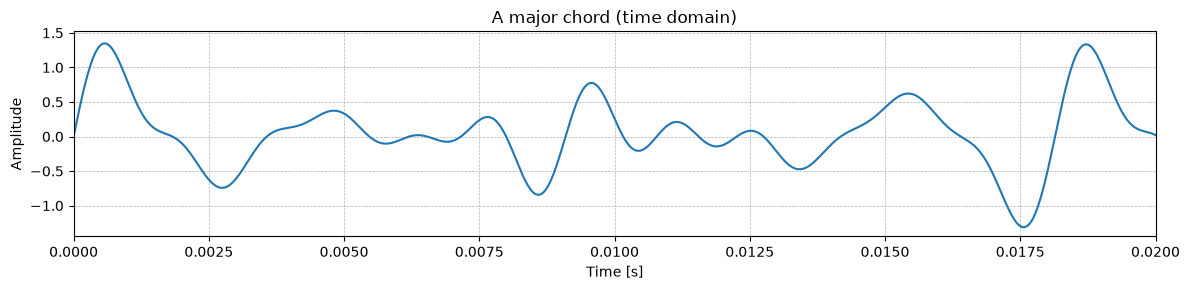

In [37]:
common.plot_signal(chord, Fs, title='A major chord (time domain)', xlim=(0, 0.02))